In [73]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("./a.jpg", cv2.IMREAD_GRAYSCALE)

max_val = int(img.max())   

bits = 0
temp = max_val
while temp > 0:
    bits += 1
    temp //= 2

L = 2 ** bits

height, width = img.shape
negative_img = np.zeros_like(img)

for i in range(height):
    for j in range(width):
        negative_img[i][j] = (L - 1) - img[i][j]



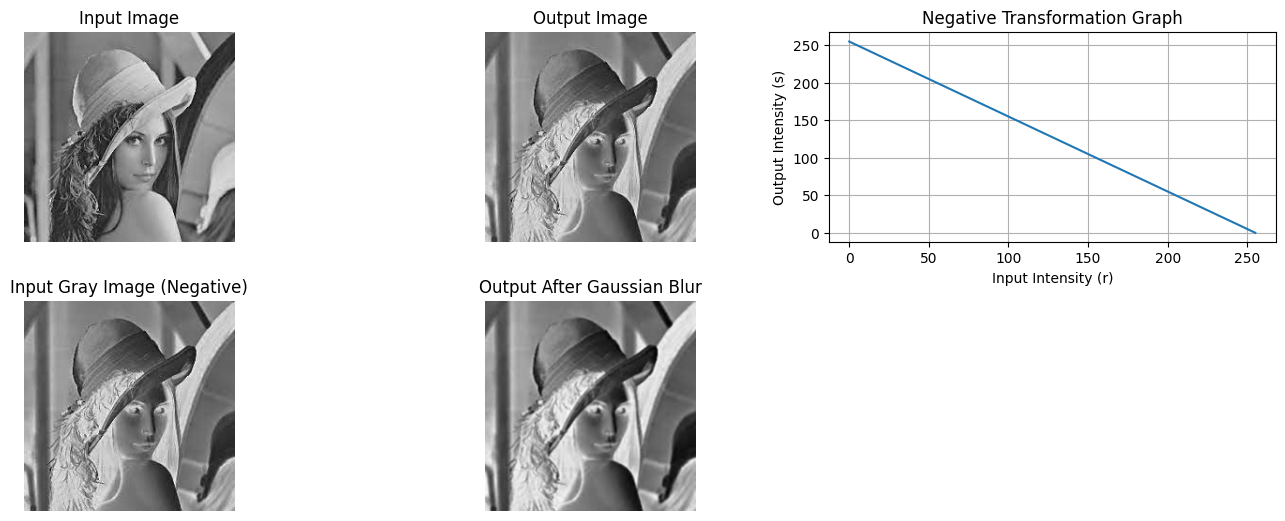

: 

In [ ]:
import numpy as np

image_gray = negative_img

k = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
]) / 16


h, w = image_gray.shape
manual_out = np.zeros_like(image_gray, dtype=float)

for i in range(1, h - 1):
    for j in range(1, w - 1):
        region = image_gray[i-1:i+2, j-1:j+2]
        manual_out[i, j] = np.sum(region * k)

manual_out_final = manual_out[1:h-1, 1:w-1].astype(np.uint8)

plt.figure(figsize=(14,8))

plt.subplot(3,3,1)
plt.imshow(img, cmap='gray', vmin=0, vmax=L-1)
plt.title("Input Image")
plt.axis('off')

plt.subplot(3,3,2)
plt.imshow(negative_img, cmap='gray', vmin=0, vmax=L-1)
plt.title("Output Image")
plt.axis('off')


plt.subplot(3,3,3)
r = np.arange(0, L)
s = (L - 1) - r
plt.plot(r, s)
plt.title("Negative Transformation Graph")
plt.xlabel("Input Intensity (r)")
plt.ylabel("Output Intensity (s)")
plt.grid(True)
plt.tight_layout()



plt.subplot(3, 3, 4)
plt.imshow(negative_img, cmap='gray')
plt.title("Input Gray Image (Negative)")
plt.axis('off')

plt.subplot(3, 3, 5)
plt.imshow(manual_out_final, cmap='gray')
plt.title("Output After Gaussian Blur")
plt.axis('off')

plt.tight_layout()
plt.show()